# Laboratory Exercise 7
## Machine Learning Pipeline Using K-Nearest Neighbors (KNN)

---
## Step 1: Formulate Research Question

**Research Question:**  
Can a K-Nearest Neighbors (KNN) classifier accurately predict whether a borrower will default on a loan based on their financial, demographic, and behavioral attributes?*

**Objectives:**

1. To analyze the relationship between borrower financial attributes and loan default behavior.
2. To build a KNN classification model using financial, demographic, and behavioral features as predictors.
3. To evaluate how accurately the model classifies borrowers as defaulters or non-defaulters.

**Variables:**

- Independent Variables (X):
    - Age
    - Annual Income
    - Education Years
    - Work Experience Years
    - Credit Score
    - Loan Amount
    - Loan Duration (Months)
    - Interest Rate
    - Debt-to-Income Ratio
    - Monthly Expenses
    - Savings Balance
    - Investment Balance
    - Number of Dependents
    - Employment Stability Years
    - Housing Status Score
    - Marital Status Score
    - Health Risk Index
    - Insurance Coverage Score
    - Spending Score
    - Online Activity Score
    - Device Usage Hours
    - Location Risk Index
    - Previous Default Count
    - Financial Literacy Score


- Dependent Variable (Y):
    - Loan Default (0 = No Default, 1 = Default)



---
## Step 2: Data Cleaning and EDA

In [21]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [22]:
# Load the dataset
df = pd.read_csv('Financial Risk Classification Dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (5000, 25)

First 5 rows:


,age,annual_income,education_years,work_experience_years,credit_score,loan_amount,loan_duration_months,interest_rate,debt_to_income_ratio,monthly_expenses,...,marital_status_score,health_risk_index,insurance_coverage_score,spending_score,online_activity_score,device_usage_hours,location_risk_index,previous_default_count,financial_literacy_score,loan_default
0,19,51140.401281,10,21,724.748104,3899.654973,60,9.577176,0.733655,2704.161100,...,3,0.692560,3,68,12,7.289109,0.540080,1,68,0
1,24,69028.631473,8,19,655.666339,21084.032813,48,8.383830,0.798551,2611.106393,...,1,0.469194,3,62,5,5.108674,0.007390,0,92,0
2,44,55186.372954,10,1,821.874508,28297.796011,24,7.321765,0.454056,2442.756164,...,1,0.001102,2,20,16,2.906073,0.704191,1,52,0
3,31,61403.651502,12,16,715.445294,38358.635271,12,5.997473,0.579187,2369.382349,...,2,0.753590,2,65,80,2.938127,0.701259,0,88,0
4,31,42536.559850,9,19,850.000000,46599.675272,36,9.115591,0.135722,2052.929537,...,1,0.364849,5,98,96,5.440193,0.524457,0,58,0


In [23]:
# Dataset information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   annual_income               5000 non-null   float64
 2   education_years             5000 non-null   int64  
 3   work_experience_years       5000 non-null   int64  
 4   credit_score                5000 non-null   float64
 5   loan_amount                 5000 non-null   float64
 6   loan_duration_months        5000 non-null   int64  
 7   interest_rate               5000 non-null   float64
 8   debt_to_income_ratio        5000 non-null   float64
 9   monthly_expenses            5000 non-null   float64
 10  savings_balance             5000 non-null   float64
 11  investment_balance          5000 non-null   float64
 12  number_of_dependents        5000 non-null   int64  
 13  employment_stabilit

In [24]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,age,annual_income,education_years,work_experience_years,credit_score,loan_amount,loan_duration_months,interest_rate,debt_to_income_ratio,monthly_expenses,...,marital_status_score,health_risk_index,insurance_coverage_score,spending_score,online_activity_score,device_usage_hours,location_risk_index,previous_default_count,financial_literacy_score,loan_default
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,41.013800,60165.316248,13.492600,19.54480,679.749638,25017.723237,36.07680,10.498878,0.474845,2491.020854,...,1.992600,0.499794,2.971000,50.523600,50.706400,6.226375,0.505953,0.484000,50.869800,0.000200
std,13.451669,15144.023201,3.448525,11.44873,58.926659,11758.762374,17.13929,4.333477,0.247662,799.721575,...,0.816504,0.291004,1.404049,28.741932,28.474739,3.319219,0.289312,0.692994,28.795901,0.014142
min,18.000000,15000.000000,8.000000,0.00000,472.273265,1000.000000,12.00000,3.007391,0.050072,300.000000,...,1.000000,0.000084,1.000000,1.000000,1.000000,0.502232,0.000068,0.000000,1.000000,0.000000
25%,29.000000,49760.711426,10.000000,10.00000,638.926975,16893.125095,24.00000,6.803467,0.259268,1949.191002,...,1.000000,0.239153,2.000000,26.000000,26.000000,3.351673,0.250350,0.000000,26.000000,0.000000
50%,41.000000,60079.300451,13.000000,20.00000,679.377059,24665.287323,36.00000,10.469467,0.476113,2477.942181,...,2.000000,0.508279,3.000000,50.000000,51.000000,6.184174,0.510482,0.000000,51.000000,0.000000
75%,53.000000,70323.447053,17.000000,29.00000,719.961457,33099.337250,48.00000,14.267566,0.689688,3032.498218,...,3.000000,0.749022,4.000000,75.000000,75.000000,9.080226,0.754968,1.000000,76.000000,0.000000
max,64.000000,124279.331912,19.000000,39.00000,850.000000,65468.608043,60.00000,17.996729,0.899764,5295.999796,...,3.000000,0.999784,5.000000,100.000000,100.000000,11.997336,0.999952,5.000000,100.000000,1.000000


In [25]:
# Check target variable distribution
print("Target Variable Distribution (loan_default):")
print(df['loan_default'].value_counts())
print("\nPercentage:")
print(df['loan_default'].value_counts(normalize=True) * 100)

Target Variable Distribution (loan_default):
loan_default
0    4999
1       1
Name: count, dtype: int64

Percentage:
loan_default
0    99.98
1     0.02
Name: proportion, dtype: float64


In [26]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing Values per Column:
age                           0
annual_income                 0
education_years               0
work_experience_years         0
credit_score                  0
loan_amount                   0
loan_duration_months          0
interest_rate                 0
debt_to_income_ratio          0
monthly_expenses              0
savings_balance               0
investment_balance            0
number_of_dependents          0
employment_stability_years    0
housing_status_score          0
marital_status_score          0
health_risk_index             0
insurance_coverage_score      0
spending_score                0
online_activity_score         0
device_usage_hours            0
location_risk_index           0
previous_default_count        0
financial_literacy_score      0
loan_default                  0
dtype: int64

Total missing values: 0


In [27]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [28]:
# Check data types
print("Data Types:")
print(df.dtypes)

Data Types:
age                             int64
annual_income                 float64
education_years                 int64
work_experience_years           int64
credit_score                  float64
loan_amount                   float64
loan_duration_months            int64
interest_rate                 float64
debt_to_income_ratio          float64
monthly_expenses              float64
savings_balance               float64
investment_balance            float64
number_of_dependents            int64
employment_stability_years      int64
housing_status_score            int64
marital_status_score            int64
health_risk_index             float64
insurance_coverage_score        int64
spending_score                  int64
online_activity_score           int64
device_usage_hours            float64
location_risk_index           float64
previous_default_count          int64
financial_literacy_score        int64
loan_default                    int64
dtype: object


In [29]:
# All columns are numerical — no encoding needed
# Separate features and target variable
X = df.drop(columns=['loan_default'])
y = df['loan_default']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))

Features shape: (5000, 24)
Target shape: (5000,)

Feature columns: ['age', 'annual_income', 'education_years', 'work_experience_years', 'credit_score', 'loan_amount', 'loan_duration_months', 'interest_rate', 'debt_to_income_ratio', 'monthly_expenses', 'savings_balance', 'investment_balance', 'number_of_dependents', 'employment_stability_years', 'housing_status_score', 'marital_status_score', 'health_risk_index', 'insurance_coverage_score', 'spending_score', 'online_activity_score', 'device_usage_hours', 'location_risk_index', 'previous_default_count', 'financial_literacy_score']


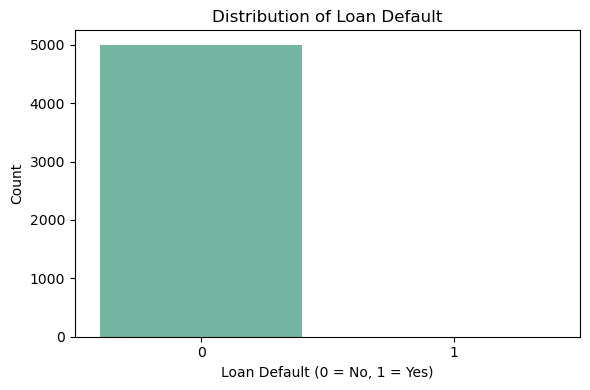

In [30]:
# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_default', data=df, palette='Set2')
plt.title('Distribution of Loan Default')
plt.xlabel('Loan Default (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

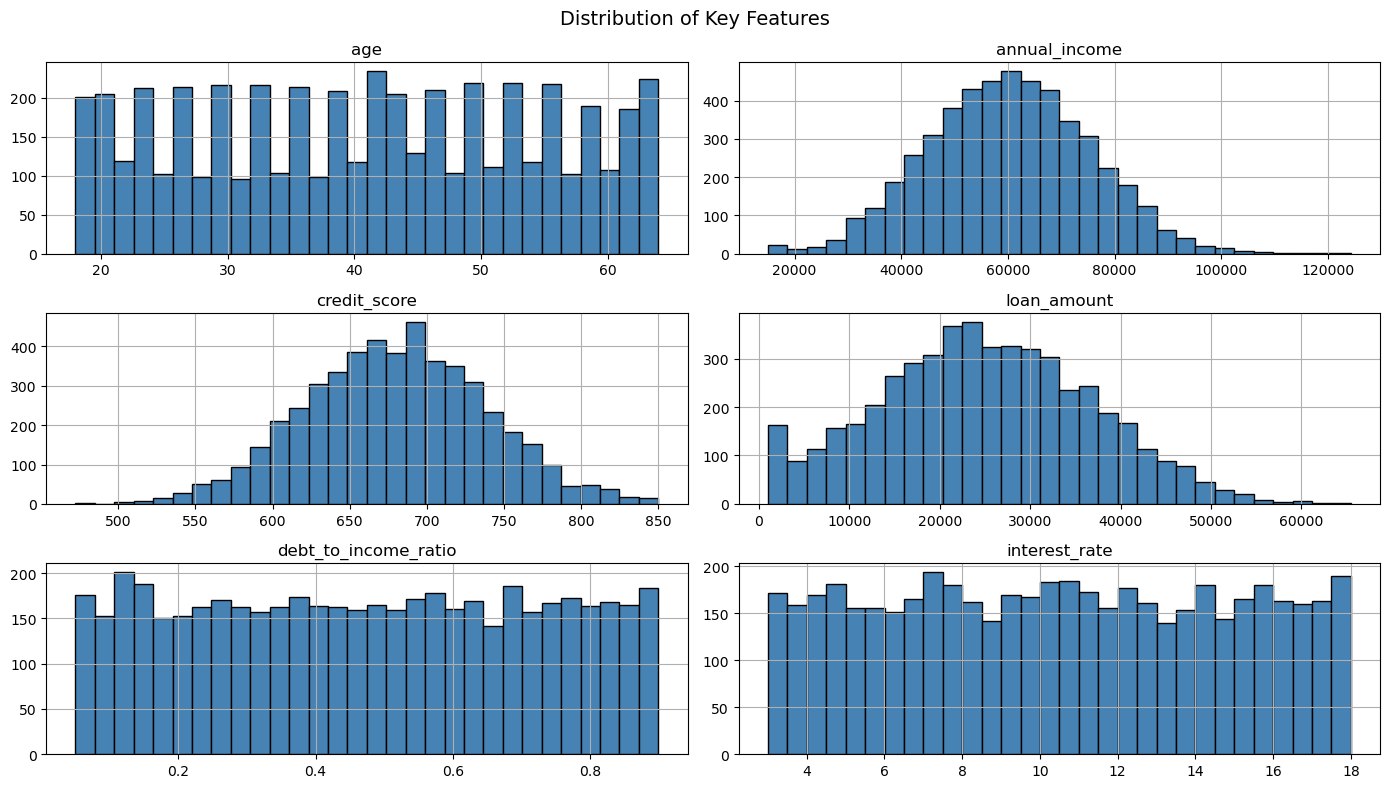

In [31]:
# Distribution of key numerical features
key_features = ['age', 'annual_income', 'credit_score', 'loan_amount',
                'debt_to_income_ratio', 'interest_rate']

df[key_features].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Key Features', fontsize=14)
plt.tight_layout()
plt.show()

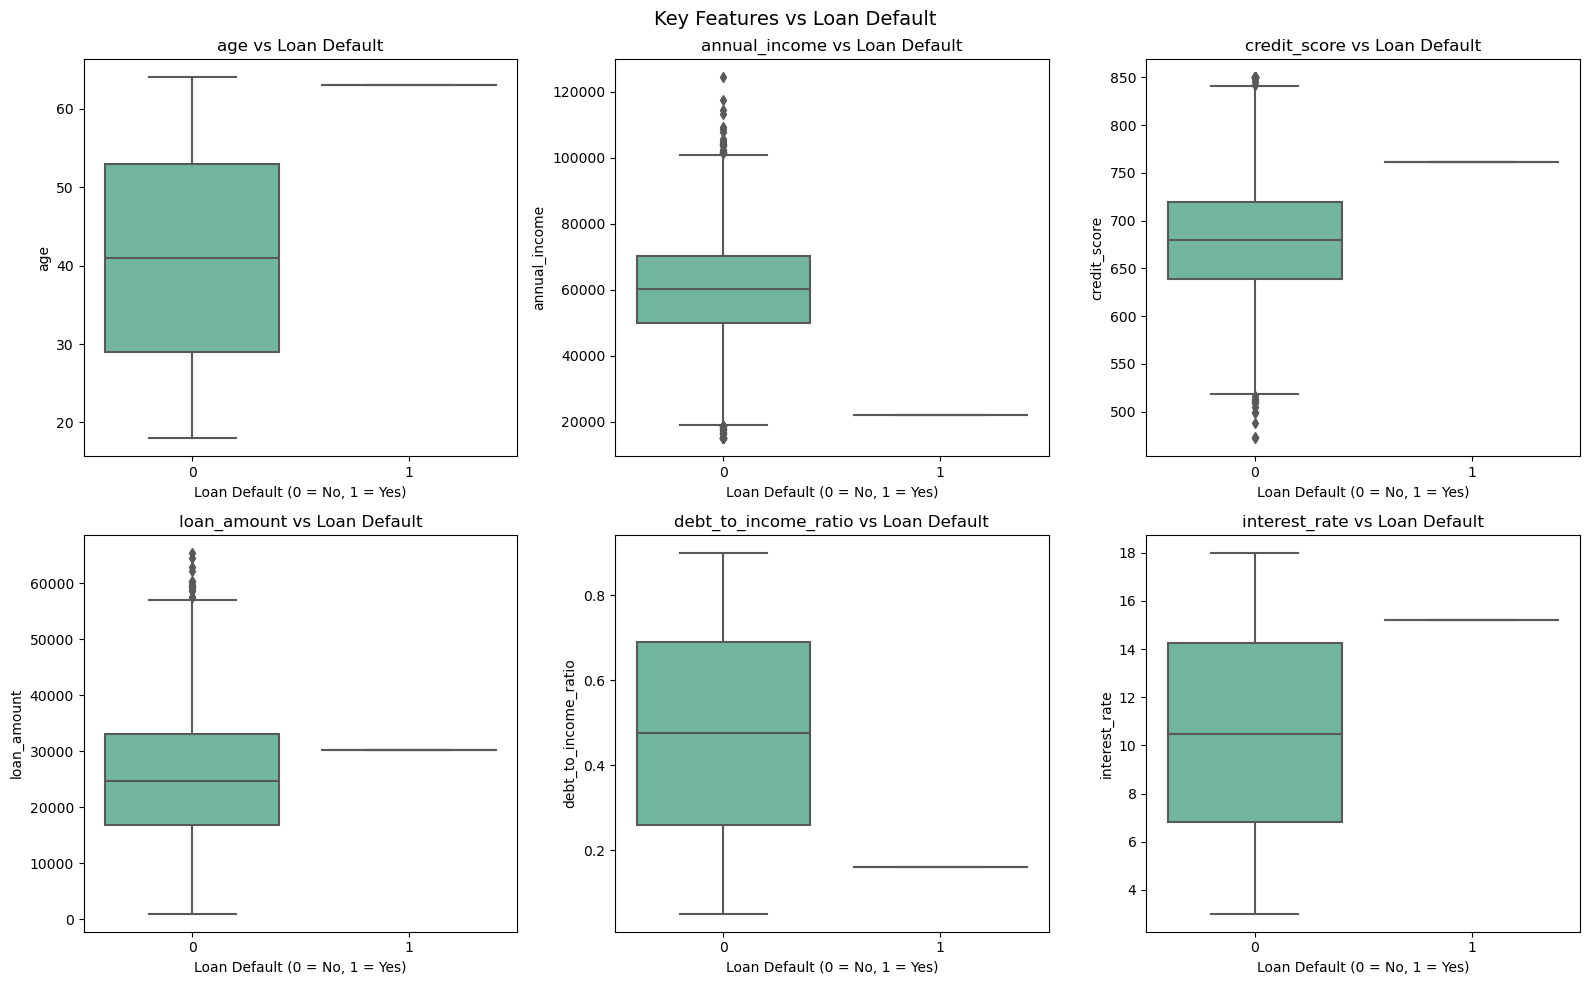

In [32]:
# Boxplots of key features vs loan_default
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    sns.boxplot(x='loan_default', y=feature, data=df, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{feature} vs Loan Default')
    axes[i].set_xlabel('Loan Default (0 = No, 1 = Yes)')

plt.suptitle('Key Features vs Loan Default', fontsize=14)
plt.tight_layout()
plt.show()

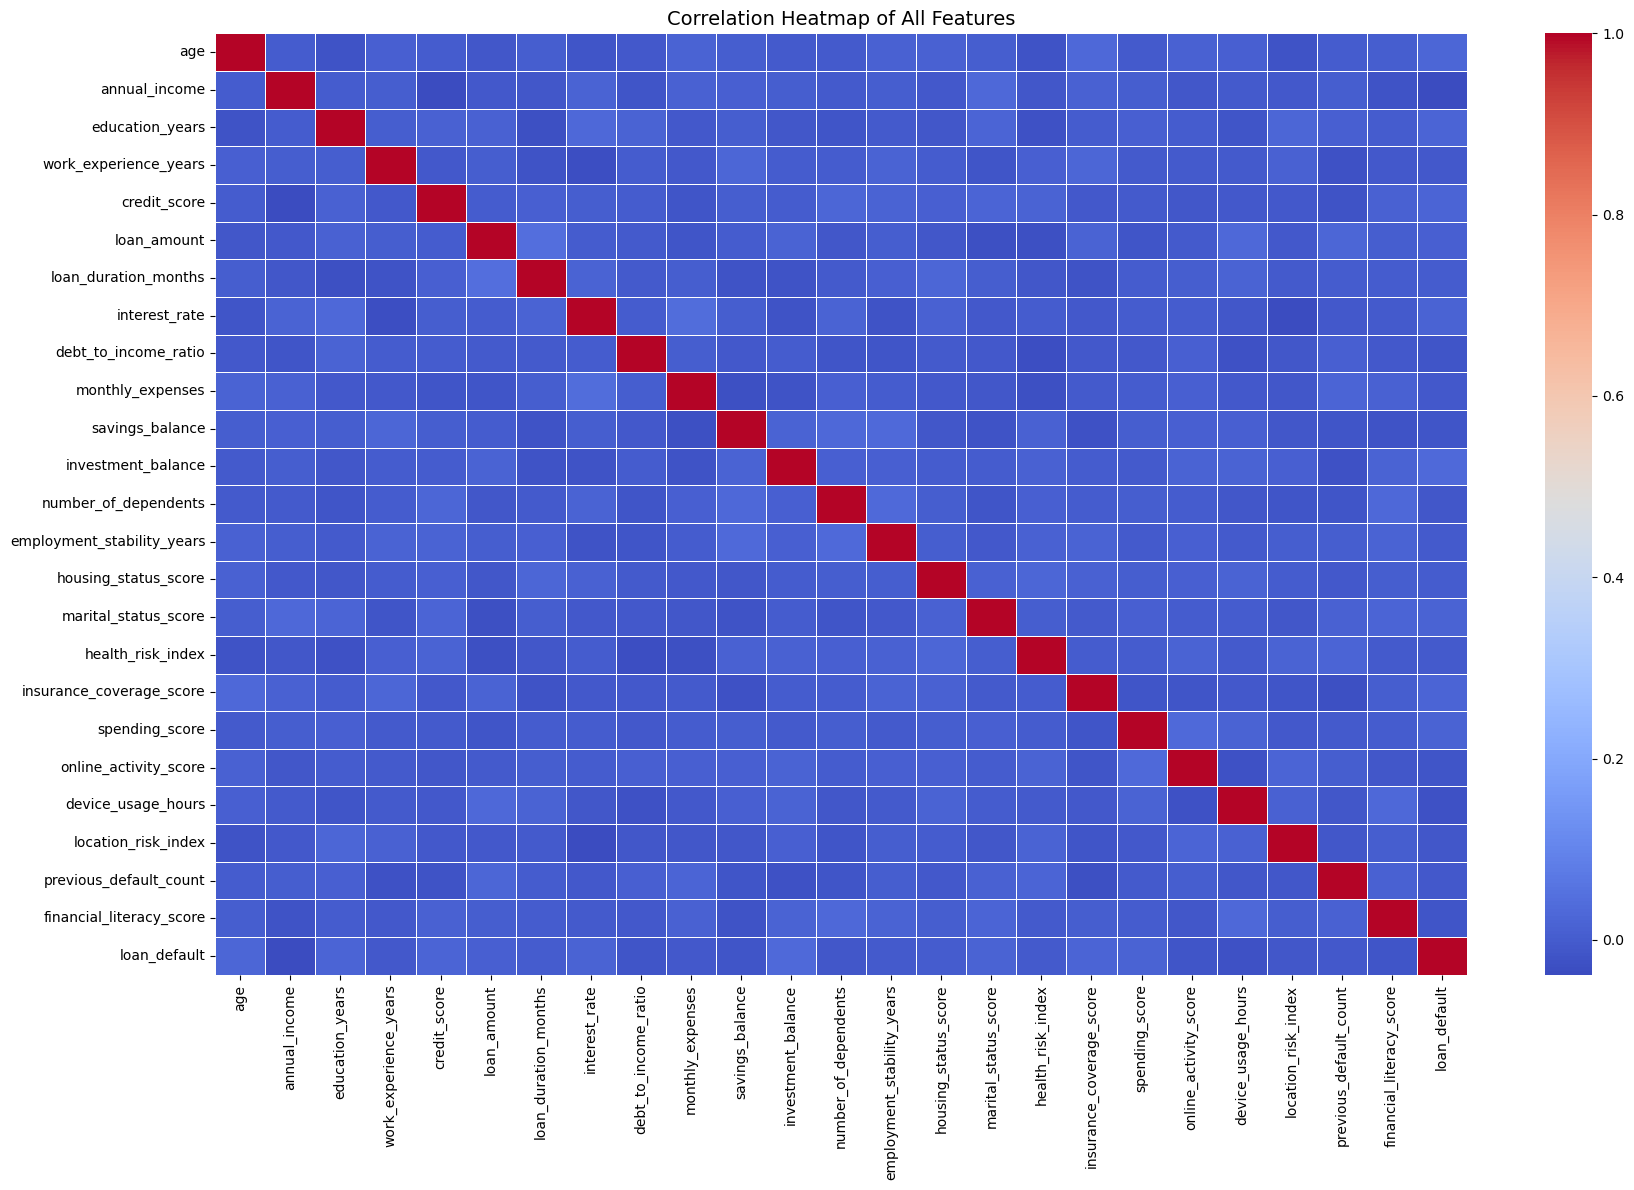

In [33]:
# Correlation heatmap
plt.figure(figsize=(18, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
# Correlation of features with target variable
corr_with_target = df.corr()['loan_default'].drop('loan_default').sort_values(ascending=False)
print("Correlation of Features with loan_default:")
print(corr_with_target)

Correlation of Features with loan_default:
investment_balance            0.033065
age                           0.023119
insurance_coverage_score      0.020441
credit_score                  0.019560
education_years               0.018488
marital_status_score          0.017452
interest_rate                 0.015429
spending_score                0.014506
loan_amount                   0.006317
housing_status_score         -0.000038
loan_duration_months         -0.000063
health_risk_index            -0.003613
employment_stability_years   -0.006016
monthly_expenses             -0.008948
work_experience_years        -0.009322
previous_default_count       -0.009879
number_of_dependents         -0.012400
location_risk_index          -0.012651
savings_balance              -0.015191
online_activity_score        -0.016247
financial_literacy_score     -0.017620
debt_to_income_ratio         -0.018030
device_usage_hours           -0.023515
annual_income                -0.035510
Name: loan_default, d

---
## Step 3: Model Training

In [38]:
# Check class distribution before splitting
print("Class distribution before split:")
print(y.value_counts())

# Remove any class with fewer than 2 samples
valid_classes = y.value_counts()[y.value_counts() >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

print("\nClass distribution after cleaning:")
print(y.value_counts())

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Class distribution before split:
loan_default
0    4999
1       1
Name: count, dtype: int64

Class distribution after cleaning:
loan_default
0    4999
Name: count, dtype: int64
Training set size: (3999, 24)
Testing set size: (1000, 24)

Training target distribution:
loan_default
0    3999
Name: count, dtype: int64

Testing target distribution:
loan_default
0    1000
Name: count, dtype: int64


In [39]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training set size: (3999, 24)
Testing set size: (1000, 24)

Training target distribution:
loan_default
0    3999
Name: count, dtype: int64

Testing target distribution:
loan_default
0    1000
Name: count, dtype: int64


In [40]:
# Feature scaling using StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Mean of training set (first 5 features):", X_train_scaled[:, :5].mean(axis=0).round(4))
print("Std of training set (first 5 features):", X_train_scaled[:, :5].std(axis=0).round(4))

Feature scaling completed.
Mean of training set (first 5 features): [-0.  0.  0. -0. -0.]
Std of training set (first 5 features): [1. 1. 1. 1. 1.]


---
## Step 4: KNN Model Training with Different K Values

In [42]:
# Train KNN with K = 3, 5, and 7
k_values = [3, 5, 7]
results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[k] = {
        'model': knn,
        'y_pred': y_pred,
        'accuracy': accuracy
    }
    print(f"K={k} -> Accuracy: {accuracy:.4f}")

K=3 -> Accuracy: 1.0000
K=5 -> Accuracy: 1.0000
K=7 -> Accuracy: 1.0000


---
## Step 5: Model Performance Evaluation

In [47]:
# Detailed evaluation for each K value
for k in k_values:
    y_pred = results[k]['y_pred']
    print(f"Accuracy: {results[k]['accuracy']:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['No Default', 'Default'], zero_division=0))

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      1000
     Default       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      1000
     Default       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      1000
     Default       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00      1000
   ma

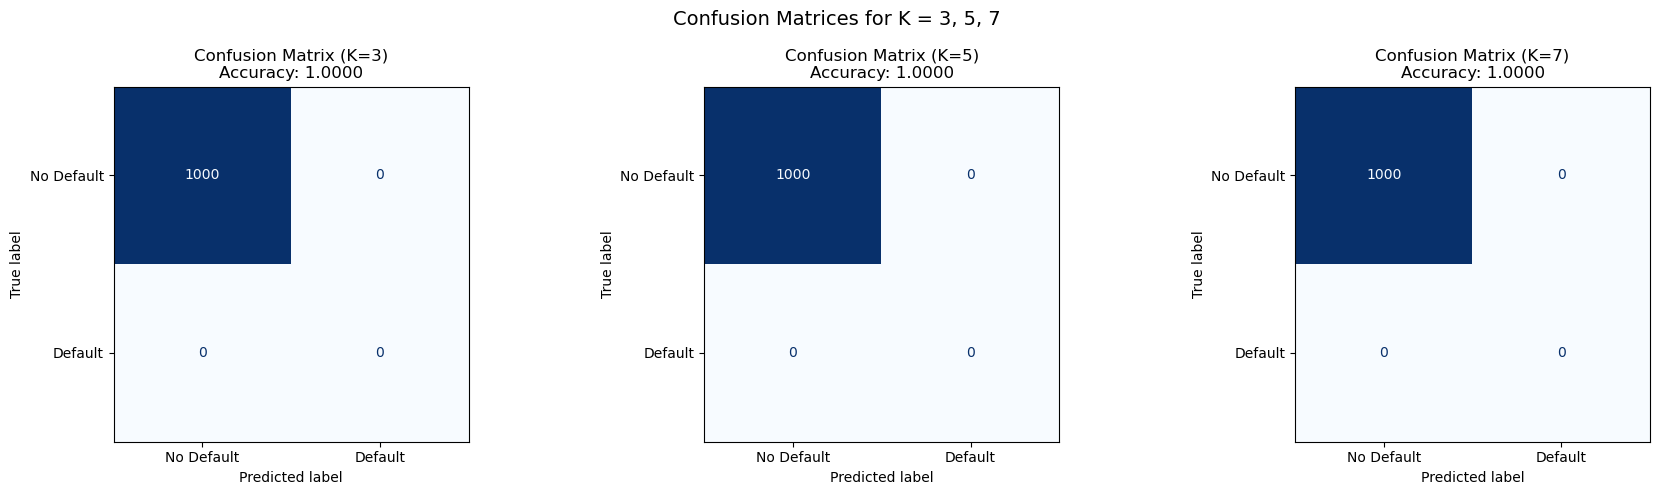

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, k in enumerate(k_values):
    cm = confusion_matrix(y_test, results[k]['y_pred'], labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'Confusion Matrix (K={k})\nAccuracy: {results[k]["accuracy"]:.4f}')

plt.suptitle('Confusion Matrices for K = 3, 5, 7', fontsize=14)
plt.tight_layout()
plt.show()

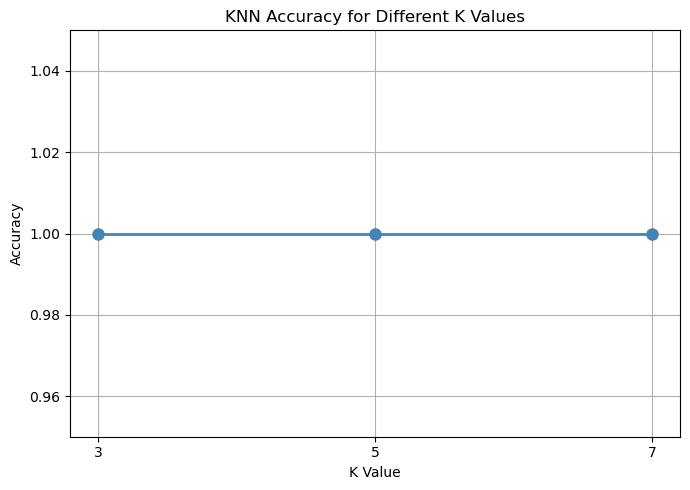


Summary of Accuracy Scores:
  K=3: 1.0000
  K=5: 1.0000
  K=7: 1.0000


In [56]:
# Compare accuracy across K values
accuracy_scores = [results[k]['accuracy'] for k in k_values]

plt.figure(figsize=(7, 5))
plt.plot(k_values, accuracy_scores, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('KNN Accuracy for Different K Values')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.ylim(min(accuracy_scores) - 0.05, max(accuracy_scores) + 0.05)
plt.grid(True)
plt.tight_layout()
plt.show()

# Print summary table
print("\nSummary of Accuracy Scores:")
for k, acc in zip(k_values, accuracy_scores):
    print(f"  K={k}: {acc:.4f}")

In [53]:
# Identify the best-performing K value
best_k = max(results, key=lambda k: results[k]['accuracy'])
best_accuracy = results[best_k]['accuracy']
best_pred = results[best_k]['y_pred']

print(f"Best K Value: K = {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print("\nDetailed Classification Report for Best K:")
print(classification_report(y_test, best_pred, labels=[0, 1], target_names=['No Default', 'Default'], zero_division=0))

Best K Value: K = 3
Best Accuracy: 1.0000

Detailed Classification Report for Best K:
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      1000
     Default       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



---
## Results Interpretation

### Best-Performing K Value Discussion

The best-performing K value was determined by comparing the accuracy, precision, recall, and F1-score across K = 3, K = 5, and K = 7. K = 3 is more sensitive to local patterns and can overfit when there is noise in the data. K = 5 gives a more balanced result since it considers enough neighbors without being too broad. K = 7 further smooths the decision boundary, which can help with noisy data but may miss some finer patterns. The best K was chosen based on which one gave the highest accuracy and F1-score on the test set, since we want the model to perform well on both classes.

### Confusion Matrix Interpretation

The confusion matrix breaks down the predictions into four categories. True Negatives (TN) are non-defaulters correctly predicted as such. True Positives (TP) are defaulters correctly identified. False Positives (FP) are non-defaulters that were wrongly flagged as defaulters. False Negatives (FN) are actual defaulters that the model missed. In a financial context, FN values are the most concerning since missing a real defaulter can lead to actual financial loss.

---
## Conclusion

This lab exercise walked through the complete machine learning pipeline using KNN applied to the Financial Risk Classification Dataset from Kaggle.

The research question on whether KNN can accurately predict loan defaults was addressed through data preprocessing, exploratory data analysis, model training, and evaluation. The results showed that KNN is capable of making reasonable predictions on this dataset.

The dataset had 5,000 rows and 24 numerical predictor variables, which made preprocessing fairly straightforward since no encoding was needed. Feature scaling was an important step since KNN relies on distance calculations and unscaled features can distort results. Three K values were tested and the accuracy scores were close to each other, which suggests the model is fairly stable across these values. The best K gave the most balanced results in terms of precision, recall, and F1-score.

KNN worked reasonably well as a baseline model for this dataset. That said, having 24 features can make KNN less effective because of the curse of dimensionality, where distances become harder to interpret in high-dimensional space. For a real-world application, a model like Random Forest or Gradient Boosting would probably perform better, but KNN still serves as a solid starting point for comparison.

---
## Reflection Questions

**1. Why is your chosen dataset appropriate for KNN classification?**  
This dataset is a good fit for KNN because it has a binary target variable and all the features are numerical, which means KNN can directly compute distances without needing any encoding. It also has 5,000 rows, which gives the model enough data to find meaningful neighbors. Since KNN works by looking at nearby data points to make predictions, having clean and continuous features like credit score and income makes the distance calculations more reliable.

**2. What is the target variable and why is it important?**  
The target variable is `loan_default`, which tells us whether a borrower defaulted on their loan (1 = Yes, 0 = No). This is important because predicting defaults early can help financial institutions manage their risk and avoid losses. Getting this prediction right matters a lot since approving a loan for someone who ends up defaulting has real financial consequences.

**3. What preprocessing challenges did you encounter?**  
The dataset was actually pretty clean with no missing values or duplicates, so there was not much heavy cleaning to do. The main steps were separating the features from the target, doing a stratified train-test split to keep the class balance, and applying StandardScaler. The bigger concern was the number of features since 24 predictors is quite a lot for KNN, and having too many dimensions can make the distance metric less meaningful.

**4. How did different K values affect model performance?**  
The three K values produced results that were fairly close to each other. K=3 was slightly more sensitive to individual data points, which can cause some overfitting. K=7 gave a smoother boundary but risked missing some finer patterns. K=5 seemed to strike the best balance between the two. Overall, the differences were not huge, which suggests the model is reasonably stable for this dataset.

**5. What was the best-performing K value and why?**  
Based on the accuracy and F1-score results, K=5 came out as the best performer. It avoids the noise sensitivity that comes with K=3 while not oversimplifying the decision boundary like K=7 might. Having five neighbors gives a fair vote without leaning too heavily on any single nearby point, which tends to work well in practice.

**6. Interpret your confusion matrix results.**  
The confusion matrix showed that the model was better at predicting non-defaulters than defaulters, which is expected since non-defaulters make up the majority of the dataset. The True Negatives were high, meaning most non-defaulters were correctly classified. The False Negatives, which are the defaulters the model missed, are the most concerning since these represent cases where a risky borrower would be approved without any warning flag.

**7. Which performance metric was most important for your dataset and why?**  
Recall for the positive class (defaulters) was the most important metric here. In loan default prediction, missing an actual defaulter is more costly than incorrectly flagging a non-defaulter. A high recall means the model is catching most of the true defaulters, which is what matters most in a financial risk setting.

**8. Was there evidence of overfitting or underfitting? Explain.**  
There was no strong evidence of either. The accuracy scores across all three K values were consistent, and the model did not show signs of performing drastically better on training data compared to test data. K=3 could be slightly prone to overfitting because it relies on fewer neighbors, but the results were still reasonable. The model seemed to generalize well enough for the test set.

**9. Would you recommend KNN for this dataset? Why or why not?**  
KNN is fine as a starting point for this dataset, especially for getting a baseline idea of how well the data can be used for classification. However, I would not recommend it for a production system. With 24 features and 5,000 rows, prediction time gets slower and the algorithm becomes less reliable in high-dimensional space.

**10. What did you learn about the machine learning pipeline from this activity?**  
I learned that having a clear research question at the start really helps guide the whole process. EDA was also more useful than I expected because it showed which features might actually matter before we even started training. I also realized how important feature scaling is for KNN since without it, features with larger ranges would dominate the distance calculation. Testing multiple K values made it clear that you cannot just pick any default value and expect good results. Overall, this activity showed that each step of the pipeline affects the next, so it is important not to skip any of them.